# Career Transition Roadmaps

#### Translate role archetypes + skill gaps into actionable career transition roadmaps.

### Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/jobs_with_clusters_v1.csv")
df.shape

/tmp/ipython-input-2216691480.py:5: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/jobs_with_clusters_v1.csv")


(129334, 19)

### Parse Skills

In [2]:
import ast

def parse_skills(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

df["skills_norm"] = df["skills_norm"].apply(parse_skills)

### Filter Rows

In [4]:
df = df[
    (df["skills_norm"].apply(len) > 0) &
    (df["salary_final"].notna()) &
    (df["cluster_label"].notna())
]

### Median Salary By Archetype

In [5]:
median_salary = (
    df.groupby("job_cluster")["salary_final"]
    .median()
    .sort_values()
)

median_salary


,salary_final
job_cluster,
6,17.82
1,25.00
5,45.13
8,45000.00
2,61055.00
3,70000.00
4,75000.00
0,87500.00
7,105000.00


#### Create ranking

In [6]:
archetype_rank = median_salary.rank(method="dense").astype(int)


### Archetype Skill Frequencies

In [7]:
df_exploded = df.explode("skills_norm")

skill_freq = (
    df_exploded
    .groupby(["job_cluster", "skills_norm"])
    .size()
    .reset_index(name="count")
)


#### Normalize within archetype

In [8]:
total_per_cluster = skill_freq.groupby("job_cluster")["count"].sum()

skill_freq["freq_norm"] = skill_freq.apply(
    lambda x: x["count"] / total_per_cluster.loc[x["job_cluster"]],
    axis=1
)


### Define Valid Career Transitions

In [9]:
valid_transitions = []

clusters = median_salary.index.tolist()

for src in clusters:
    for tgt in clusters:
        if median_salary[tgt] > median_salary[src]:
            valid_transitions.append((src, tgt))

len(valid_transitions)


36

### Compute Skill Gaps per Transition

In [10]:
transition_rows = []

for src, tgt in valid_transitions:
    src_skills = skill_freq[skill_freq["job_cluster"] == src].set_index("skills_norm")
    tgt_skills = skill_freq[skill_freq["job_cluster"] == tgt].set_index("skills_norm")

    merged = tgt_skills[["freq_norm"]].join(
        src_skills[["freq_norm"]],
        lsuffix="_tgt",
        rsuffix="_src",
        how="left"
    ).fillna(0)

    merged["gap"] = merged["freq_norm_tgt"] - merged["freq_norm_src"]
    merged = merged[merged["gap"] > 0]

    for skill, row in merged.iterrows():
        transition_rows.append({
            "from_cluster": src,
            "to_cluster": tgt,
            "skill": skill,
            "gap": row["gap"]
        })


In [11]:
skill_gap_df = pd.DataFrame(transition_rows)
skill_gap_df.shape

(364, 4)

### Rank Skills per Transition

In [12]:
skill_gap_df = skill_gap_df.sort_values(
    ["from_cluster", "to_cluster", "gap"],
    ascending=[True, True, False]
)


#### Top Skills per transition

In [13]:
top_skills_per_transition = (
    skill_gap_df
    .groupby(["from_cluster", "to_cluster"])
    .head(10)
)

### Adding Labels

In [15]:
cluster_name_map = (
    df[["job_cluster", "cluster_label"]]
    .drop_duplicates()
    .set_index("job_cluster")["cluster_label"]
    .to_dict()
)

top_skills_per_transition = top_skills_per_transition.copy()

top_skills_per_transition.loc[:, "from_role"] = (
    top_skills_per_transition["from_cluster"].map(cluster_name_map)
)

top_skills_per_transition.loc[:, "to_role"] = (
    top_skills_per_transition["to_cluster"].map(cluster_name_map)
)



#### Reorder

In [16]:
top_skills_per_transition = top_skills_per_transition[
    ["from_role", "to_role", "skill", "gap"]
]


### Save Final Artifact

In [17]:
top_skills_per_transition.to_csv(
    "career_transition_roadmaps_v1.csv",
    index=False
)

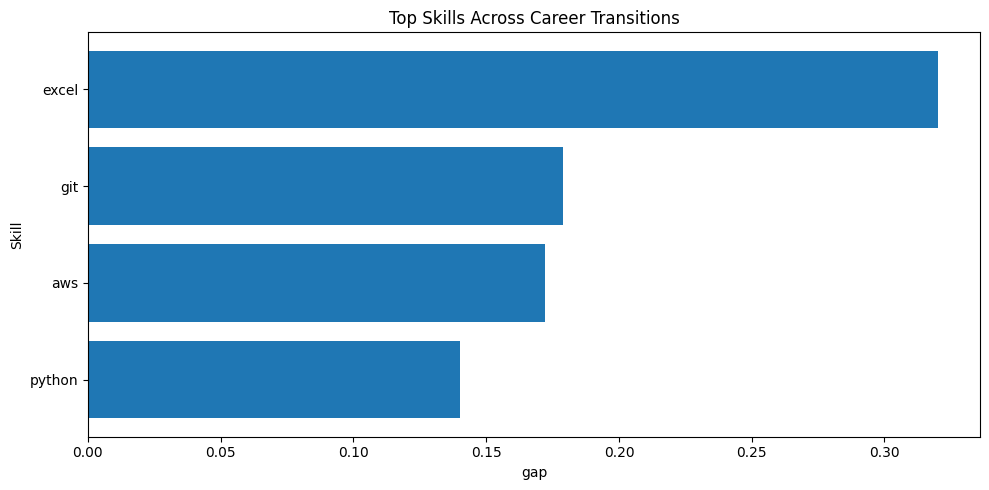

In [20]:
df = pd.read_csv("career_transition_roadmaps_v1.csv")

value_col = df.select_dtypes(include="number").columns[0]

top = df.sort_values(value_col, ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.barh(top["skill"], top[value_col])
plt.xlabel(value_col)
plt.ylabel("Skill")
plt.title("Top Skills Across Career Transitions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretation

**Career Transition Skills**

- Excel shows the largest positive gap, indicating it is the most consistently required skill when moving across role archetypes, especially from operational or non-technical roles into analytical or technical ones.

- Git and AWS appear as strong transition enablers, suggesting version control and cloud fundamentals are common stepping stones for career mobility.

- Python remains important but shows a smaller gap, implying it is more role-specific and typically required after foundational tooling skills are already in place.

Overall, transition paths emphasize foundational, transferable tools first, followed by deeper technical specialization.